
# Step 02 — Quality control and cell filtering

**Purpose.** Remove empty droplets, damaged cells and undetectable genes, using
thresholds that are looked at before they are applied.

**Why the prefixes differ from human data.** Zebrafish gene symbols are lower
case: mitochondrial genes begin `mt-`, ribosomal protein genes `rps`/`rpl`,
haemoglobins `hba`/`hbb`/`hb-`. Copying a human QC snippet (`MT-`) silently
matches nothing, `pct_counts_mt` comes out as zero for every cell, and the
mitochondrial filter quietly does nothing.

**Baseline thresholds (from the project guide).**
`min_genes = 200`, `min_cells = 3`, `pct_counts_mt < 15%`.
These stay as defaults. Any change is made in `scripts/config.py`, recorded in
`cfg.PARAM_OVERRIDES`, and justified here from the diagnostics.

In [1]:
import sys
from pathlib import Path

# Make the repository root importable regardless of where Jupyter was launched.
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "scripts").exists():
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / "scripts").exists(), (
    f"Cannot locate the repository root from {Path.cwd()}. "
    "Launch JupyterLab from the repository root."
)
sys.path.insert(0, str(REPO_ROOT))

from scripts import config as cfg
from scripts import io_utils, qc, preprocessing, clustering, annotation, egfp_analysis, plotting

cfg.ensure_directories()
plotting.set_style()
SEED = io_utils.set_seeds()
print(f"Repository root: {REPO_ROOT}")
print(f"Random seed: {SEED}")

Repository root: D:\retina\project1_zebrafish_retina
Random seed: 0


In [2]:
adata = io_utils.load_checkpoint("loaded")

Loaded 'loaded': 20097 cells x 25433 genes



## 1. Flag gene families and compute QC metrics

Nothing is filtered in this section — the metrics are needed to judge the
thresholds.

In [3]:
adata = qc.annotate_qc(adata)
display(adata.obs[["total_counts", "n_genes_by_counts",
                   "pct_counts_mt", "pct_counts_ribo", "pct_counts_hb"]].describe().round(2))

Gene families flagged: 13 mitochondrial, 94 ribosomal, 15 haemoglobin


,total_counts,n_genes_by_counts,pct_counts_mt,pct_counts_ribo,pct_counts_hb
count,20097.00,20097.00,20097.00,20097.00,20097.00
mean,4380.83,1034.40,14.82,8.00,0.32
std,19246.41,1510.86,21.04,6.21,3.63
min,500.00,32.00,0.00,0.00,0.00
25%,753.00,352.00,3.80,3.49,0.00
50%,1158.00,519.00,7.57,6.45,0.00
75%,2339.00,1000.00,13.02,10.49,0.00
max,713522.00,14693.00,97.94,53.73,86.10


In [4]:
qc_before = qc.qc_summary_table(adata, stage="before_filter")
display(qc_before)

,stage,sample,condition,n_cells,median_genes,median_counts,median_mt_percent,median_ribo_percent,median_hb_percent
0,before_filter,ctrl1,ctrl,1155,574.0,1146.0,5.96,3.25,0.0
1,before_filter,ctrl2,ctrl,2116,572.5,975.5,5.48,2.45,0.0
2,before_filter,3dp1,3dp,2873,453.0,1095.0,8.74,6.90,0.0
3,before_filter,3dp2,3dp,2388,597.5,1308.5,6.20,5.87,0.0
4,before_filter,7dp1,7dp,3444,401.0,1012.5,10.30,8.93,0.0
5,before_filter,7dp2,7dp,1480,594.0,1314.0,6.31,4.77,0.0
6,before_filter,10dp1,10dp,4124,504.0,1232.0,8.09,8.03,0.0
7,before_filter,10dp2,10dp,2517,599.0,1275.0,6.65,6.24,0.0



## 2. Figure 1 — QC diagnostics

Violins by sample with the thresholds drawn on, a counts-vs-genes scatter coloured
by mitochondrial content, and the filtering waterfall.

In [5]:
diagnostics = qc.threshold_diagnostics(adata)
display(diagnostics)

for note in qc.interpret_thresholds(diagnostics):
    print(f"- {note}")

,sample,fail_min_genes,fail_max_mt,n_cells,pct_min_genes,pct_max_mt,fail_any,pct_any
0,ctrl1,59,244,1155,5.11,21.13,249,21.56
1,ctrl2,170,507,2116,8.03,23.96,507,23.96
2,3dp1,96,543,2873,3.34,18.90,556,19.35
3,3dp2,172,543,2388,7.20,22.74,544,22.78
4,7dp1,187,849,3444,5.43,24.65,882,25.61
5,7dp2,70,303,1480,4.73,20.47,315,21.28
6,10dp1,109,788,4124,2.64,19.11,791,19.18
7,10dp2,17,359,2517,0.68,14.26,360,14.30


- Largest loss: 7dp1 at 25.6% of cells failing at least one criterion.
- The mitochondrial cut alone removes >20% of cells somewhere. Injured retina dissociates harder than control, so a condition-dependent loss here is itself a result worth reporting, not just a technical nuisance.



### Interpretation — do the baseline thresholds fit these data?

Work through these before filtering:

1. **Is the loss even across samples?** A much larger loss in the injured samples
   is expected (MNU damages the outer nuclear layer, and damaged cells dissociate
   into stressed, high-mitochondrial singlets) — but it means the surviving cell
   population is not sampled identically across conditions, which propagates into
   every proportion in Figure 5.
2. **Does the mitochondrial distribution have a clear shoulder?** If the bulk of
   cells sit well under 15% and a distinct tail sits above, the threshold is doing
   what it should. If the distribution is smooth through 15%, the cut is arbitrary
   and the number of cells it removes should be reported as a sensitivity note.
3. **Is anything lost at `min_genes = 200`?** Cell Ranger's *filtered* matrix has
   already removed most empty droplets, so this filter often removes very little.
   That is normal, not a bug.

In [6]:
adata_filtered, filter_log = qc.filter_cells_and_genes(adata)
display(filter_log)

Cells: 20097 -> 15893 (79.1% kept)
Genes: 25433 -> 22813


,step,cells,genes,cells_lost
0,input,20097,25433,0
1,min_genes>=200,19217,25433,880
2,pct_mt<15.0,15893,25433,3324
3,min_cells>=3,15893,22813,0


Saved figure_01_qc_overview -> figures\figure_01_qc/ (png, pdf)


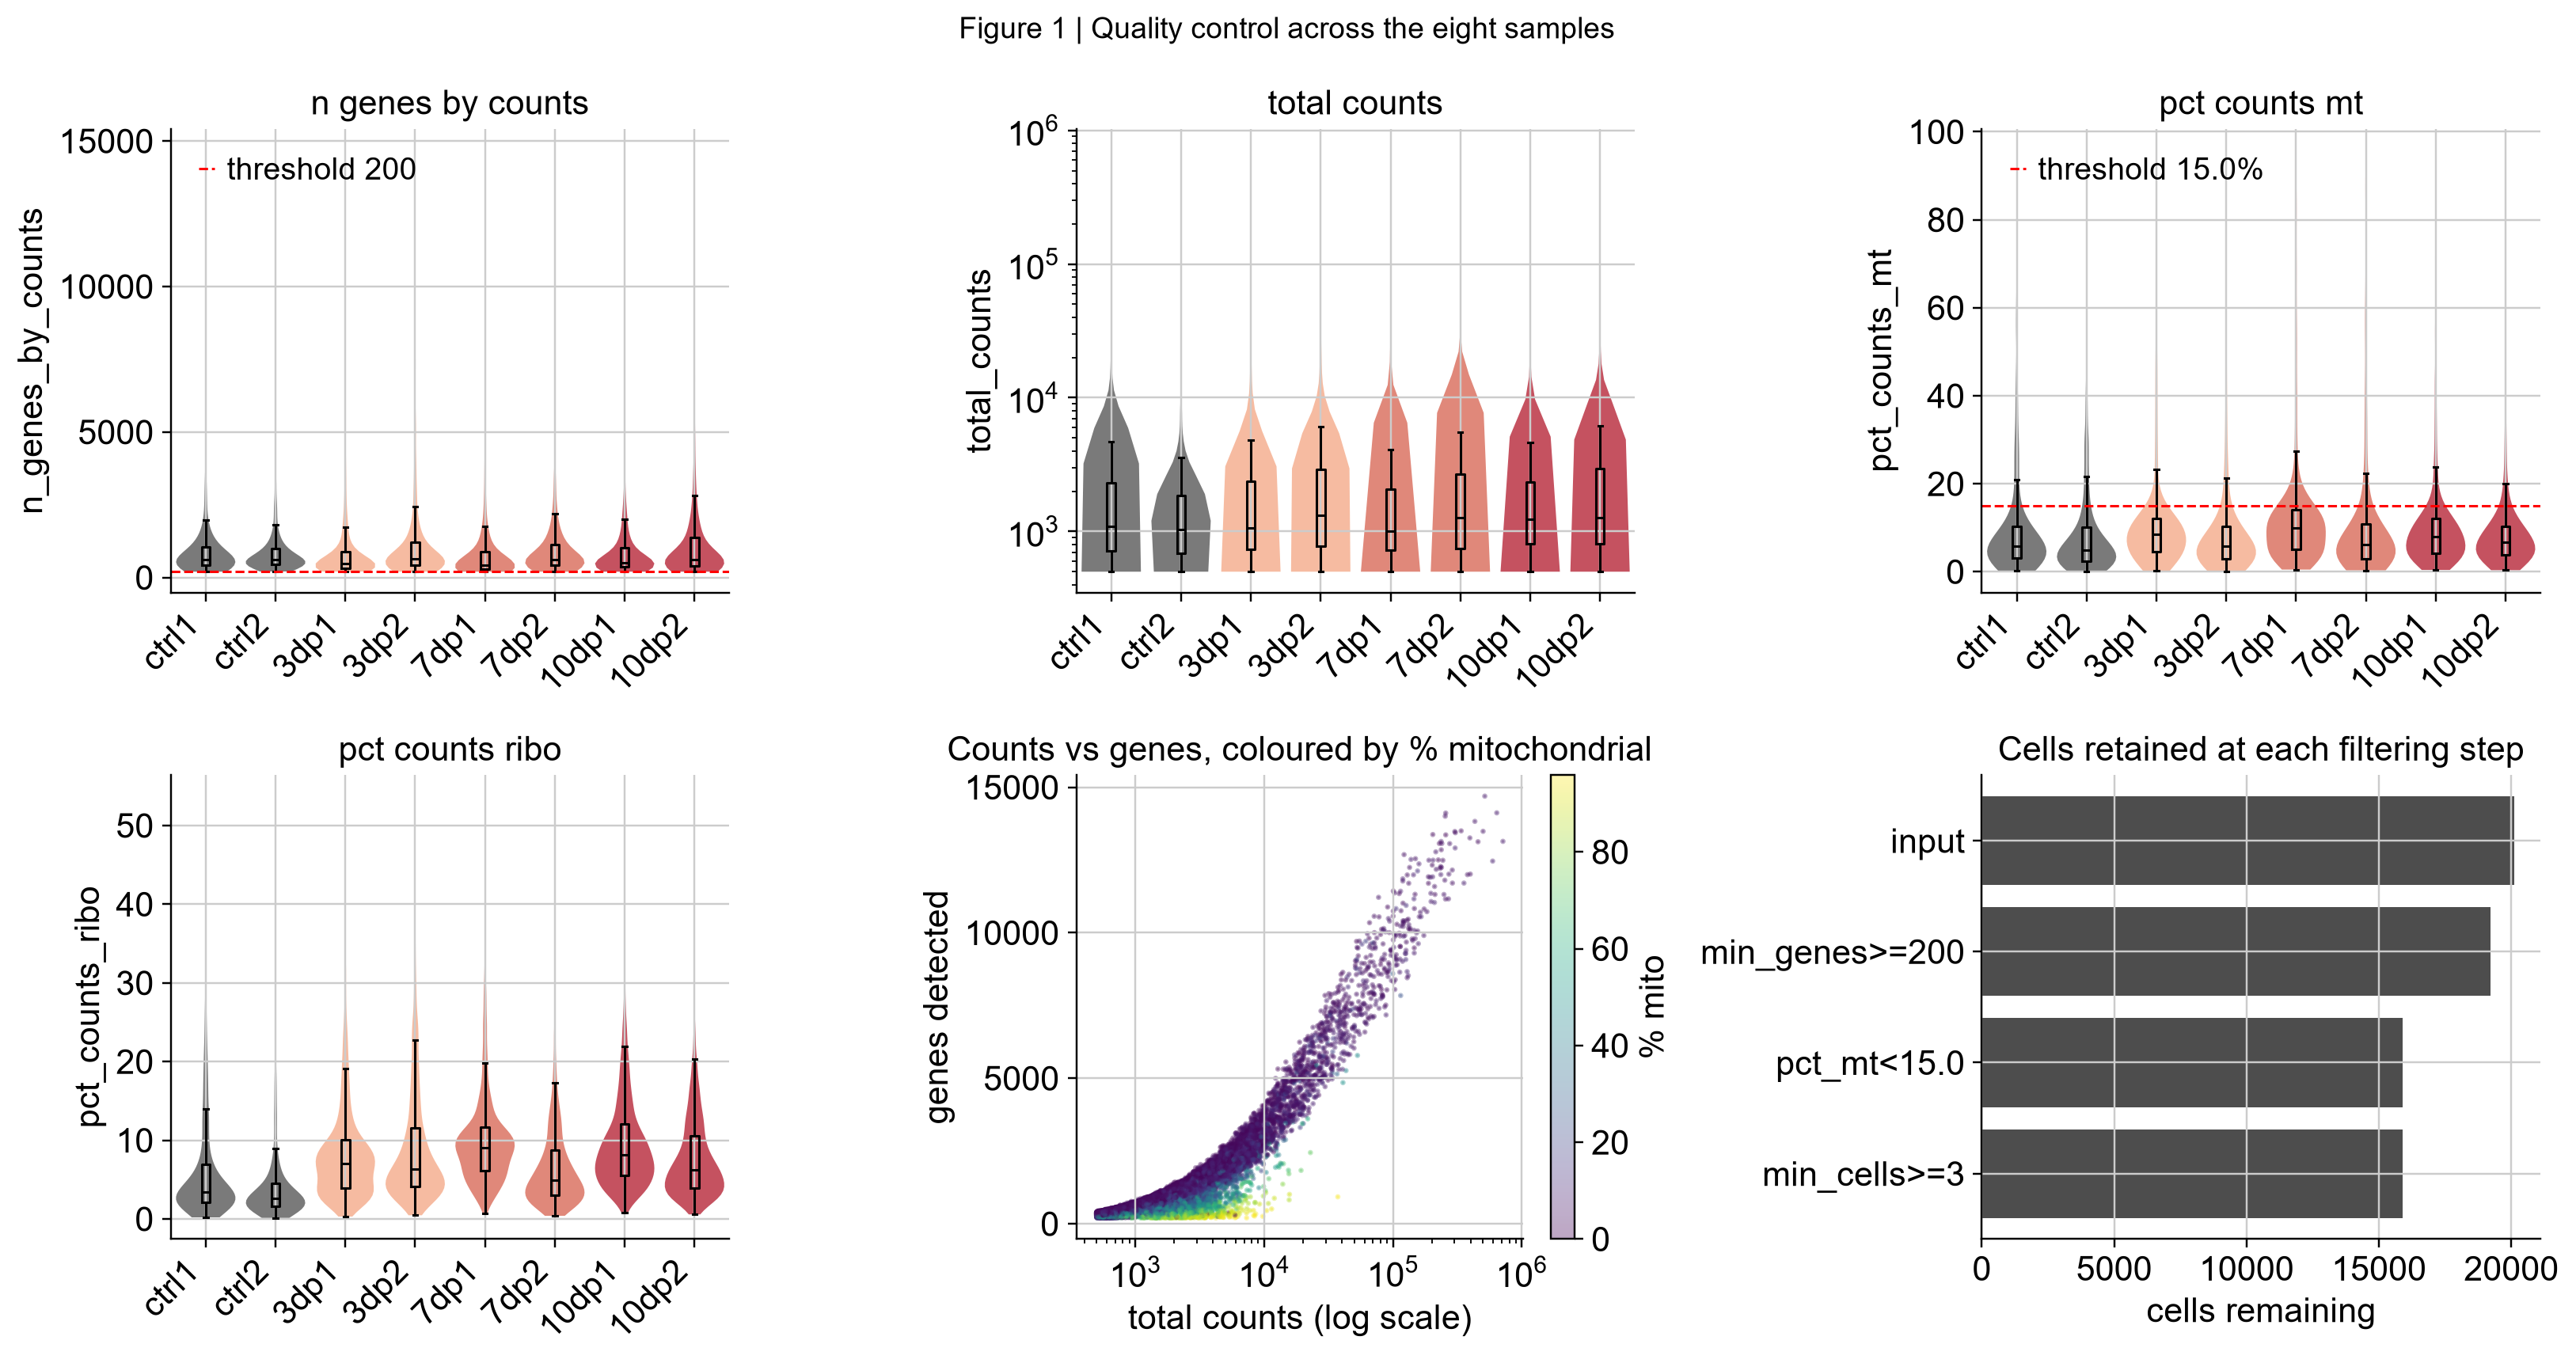

In [7]:
fig = plotting.figure_01_qc(adata, filter_log=filter_log)

In [8]:
import pandas as pd

qc_after = qc.qc_summary_table(adata_filtered, stage="after_filter")
qc_summary = pd.concat([qc_before, qc_after], ignore_index=True)
io_utils.save_table(qc_summary, "qc_summary.csv")
display(qc_after)

Wrote tables\qc_summary.csv  (16 rows)


,stage,sample,condition,n_cells,median_genes,median_counts,median_mt_percent,median_ribo_percent,median_hb_percent
0,after_filter,ctrl1,ctrl,906,614.5,993.5,4.76,3.57,0.0
1,after_filter,ctrl2,ctrl,1609,638.0,987.0,3.94,2.74,0.0
2,after_filter,3dp1,3dp,2317,448.0,945.0,7.33,7.52,0.0
3,after_filter,3dp2,3dp,1844,674.0,1225.5,4.62,6.83,0.0
4,after_filter,7dp1,7dp,2562,446.0,964.0,7.98,9.25,0.0
5,after_filter,7dp2,7dp,1165,658.0,1189.0,4.97,5.09,0.0
6,after_filter,10dp1,10dp,3333,525.0,1163.0,6.50,8.56,0.0
7,after_filter,10dp2,10dp,2157,626.0,1222.0,5.70,6.59,0.0


In [9]:
cell_counts = qc.per_sample_cell_counts(adata_filtered)
io_utils.save_table(cell_counts, "cell_counts_by_sample.csv")
display(cell_counts)

Wrote tables\cell_counts_by_sample.csv  (8 rows)


,sample,condition,replicate,n_cells,pct_of_dataset
0,ctrl1,ctrl,1,906,5.70
1,ctrl2,ctrl,2,1609,10.12
2,3dp1,3dp,1,2317,14.58
3,3dp2,3dp,2,1844,11.60
4,7dp1,7dp,1,2562,16.12
5,7dp2,7dp,2,1165,7.33
6,10dp1,10dp,1,3333,20.97
7,10dp2,10dp,2,2157,13.57



## 3. Transgene detectability after QC

Recorded here so the Methods section can state the EGFP detection rate on the
filtered data, which is the population every later figure uses.

In [10]:
egfp_name = io_utils.find_egfp_feature(adata_filtered, verbose=False)
print(qc.egfp_qc_note(adata_filtered, egfp_name))

EGFP feature 'EGFP': 481 of 15893 cells (3.03%) have >= 1 count(s); max 256 counts in a single cell.


In [11]:
adata = adata_filtered
io_utils.save_checkpoint(adata, "qc_filtered")

Saved checkpoint 'qc_filtered' -> results\02_qc_filtered.h5ad (46.6 MB)


WindowsPath('D:/retina/project1_zebrafish_retina/results/02_qc_filtered.h5ad')


### What to check before continuing

- [ ] `pct_counts_mt` is **not** identically zero (if it is, the `mt-` prefix matched nothing).
- [ ] Total retained cells is a sensible fraction of the input (roughly 80–95% is typical here).
- [ ] Cell loss per sample is recorded, and any condition-dependent loss is noted for the Discussion.
- [ ] `tables/qc_summary.csv` and `tables/cell_counts_by_sample.csv` exist.
- [ ] Figure 1 saved as PNG **and** PDF.